
ANÁLISIS ESTADÍSTICO GENERAL



,Métrica,Valor
0,Media,65785.42
1,Mediana,65525.00
2,Moda,Cáncer
3,Varianza,8682849.17
4,Desviación Estándar,2946.67



ANÁLISIS DE MUERTES

Signo con más muertes (general): Cáncer
Signo con más muertes (hombres): Cáncer
Signo con más muertes (mujeres): Cáncer
Murieron más hombres

RESUMEN ESTADÍSTICO DE LA TABLA



SEXO,9,Hombre,Mujer
count,12.00,12.00,12.00
mean,6.17,36517.67,29261.58
std,1.19,1557.47,1448.31
min,4.00,34428.00,27310.00
25%,5.75,35219.25,28132.75
50%,6.00,36320.50,29380.00
75%,7.00,37722.50,29972.00
max,8.00,39359.00,32361.00


C:\Users\Katia\AppData\Local\Temp\ipykernel_15560\1815121695.py:167: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


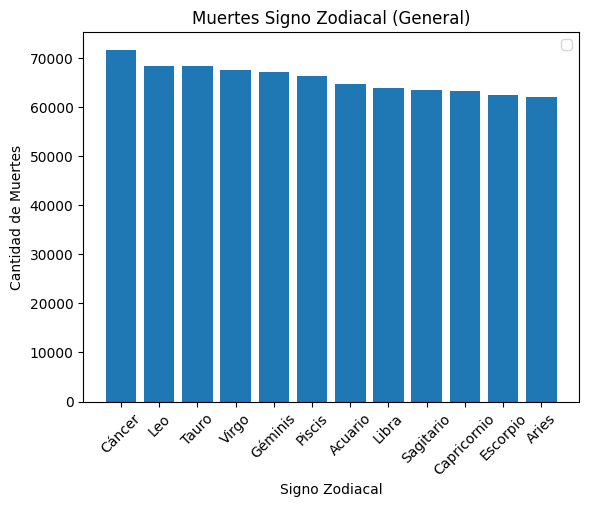

C:\Users\Katia\AppData\Local\Temp\ipykernel_15560\1815121695.py:177: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


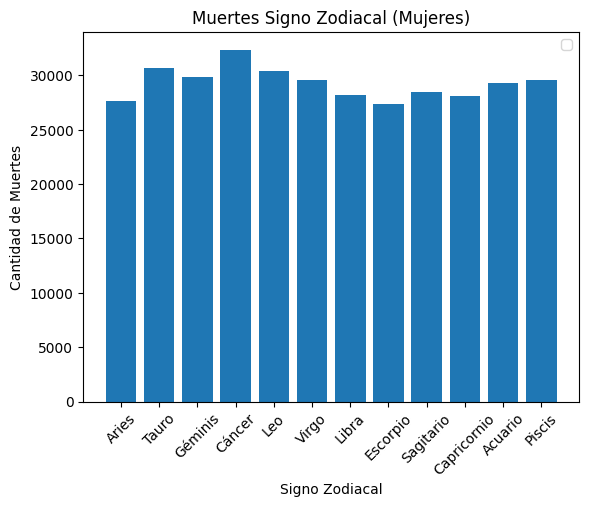

C:\Users\Katia\AppData\Local\Temp\ipykernel_15560\1815121695.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


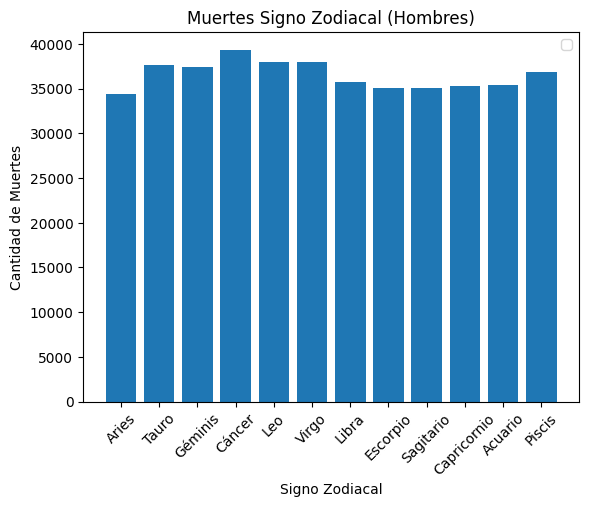


TABLA SIGNO vs SEXO



SEXO,9,Hombre,Mujer
SIGNO_ZODIACAL,,,
Aries,6,34428,27612
Tauro,8,37634,30630
Géminis,8,37399,29832
Cáncer,4,39359,32361
Leo,6,37988,30392
Virgo,7,38002,29568
Libra,7,35753,28151
Escorpio,5,35079,27310
Sagitario,5,35026,28445


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("defunciones_registradas_2023.csv")

df_zodiaco = data[['DIA_NACIM', 'MES_NACIM', 'ANIO_NACIM', 'SEXO']].copy()

def signoZodiacal(fila):
    dia = fila['DIA_NACIM']
    mes = fila['MES_NACIM']

    if (mes == 3 and dia >= 21) or (mes == 4 and dia <= 19):
        return "Aries"
    elif(mes == 4 and dia >= 20) or (mes == 5 and dia <= 20):
        return "Tauro"
    elif(mes == 5 and dia >= 21) or (mes == 6 and dia <= 20):
        return "Géminis"
    elif(mes == 6 and dia >= 21) or (mes == 7 and dia <= 22):
        return "Cáncer" 
    elif(mes == 7 and dia >= 23) or (mes == 8 and dia <= 22):
        return "Leo"
    elif (mes == 8 and dia >= 23) or (mes == 9 and dia <= 22):
        return "Virgo"
    elif (mes == 9 and dia >= 23) or (mes == 10 and dia <= 22):
        return "Libra"
    elif (mes == 10 and dia >= 23) or (mes == 11 and dia <= 21):
        return "Escorpio"
    elif (mes == 11 and dia >= 22) or (mes == 12 and dia <= 21):
        return "Sagitario"
    elif (mes == 12 and dia >= 22) or (mes == 1 and dia <= 19):
        return "Capricornio"
    elif (mes == 1 and dia >= 20) or (mes == 2 and dia <= 18):
        return "Acuario"
    elif (mes == 2 and dia >= 19) or (mes == 3 and dia <= 20):
        return "Piscis"

df_zodiaco['SIGNO_ZODIACAL'] = df_zodiaco.apply(signoZodiacal, axis=1)

df_zodiaco['SEXO'] = df_zodiaco['SEXO'].replace({1: 'Hombre', 2: 'Mujer'})

frecuencias = df_zodiaco['SIGNO_ZODIACAL'].value_counts()
valores = list(frecuencias.values)

# MEDIA
suma = 0
for i in range(len(valores)):
    suma = suma + valores[i]

media = suma / len(valores)

# MEDIANA
ordenados = sorted(valores)
n = len(ordenados)

if n % 2 == 0:
    mediana = (ordenados[n//2 - 1] + ordenados[n//2]) / 2
else:
    mediana = ordenados[n//2]

# MODA
conteo = {}

for signo in df_zodiaco['SIGNO_ZODIACAL']:
    if signo in conteo:
        conteo[signo] += 1
    else:
        conteo[signo] = 1

mayor = 0
moda = None

for signo in conteo:
    if conteo[signo] > mayor:
        mayor = conteo[signo]
        moda = signo

# DESVIACIÓN ESTÁNDAR
suma = 0
for x in valores:
    suma += (x - media) ** 2

varianza = suma / (len(valores) - 1)
desviacion_estandar = varianza ** 0.5

resumen = {
    "Métrica": ["Media", "Mediana", "Moda", "Varianza", "Desviación Estándar"],
    "Valor": [f"{media:.2f}", f"{mediana:.2f}", moda, f"{varianza:.2f}", f"{desviacion_estandar:.2f}"]
}

df_resumen = pd.DataFrame(resumen)

print("\nANÁLISIS ESTADÍSTICO GENERAL\n")
display(df_resumen)

tabla = pd.crosstab(df_zodiaco['SIGNO_ZODIACAL'], df_zodiaco['SEXO'])

signos = list(tabla.index)
listah = list(tabla['Hombre'])
listam = list(tabla['Mujer'])

mayor_total = -1
mayorh = -1
mayorm = -1

total_signos = None
signoh = None
signom = None

totalh = 0
totalm = 0

for i in range(len(signos)):

    h = listah[i]
    m = listam[i]
    total = h + m

    totalh += h
    totalm += m

    if total > mayor_total:  
        mayor_total = total
        total_signos = signos[i]

    if h > mayorh:
        mayorh = h
        signoh = signos[i]

    if m > mayorm:
        mayorm = m
        signom = signos[i]


print("\nANÁLISIS DE MUERTES\n")
print("Signo con más muertes (general):", total_signos)
print("Signo con más muertes (hombres):", signoh)
print("Signo con más muertes (mujeres):", signom)

if totalh > totalm:
    print("Murieron más hombres")
elif totalm > totalh:
    print("Murieron más mujeres")
else:
    print("Murieron igual cantidad")


tabla = pd.crosstab(df_zodiaco['SIGNO_ZODIACAL'], df_zodiaco['SEXO'])

orden_signos = [
    "Aries", "Tauro", "Géminis", "Cáncer", "Leo", "Virgo",
    "Libra", "Escorpio", "Sagitario", "Capricornio", "Acuario", "Piscis"
]

tabla = tabla.reindex(orden_signos).fillna(0)

print("\nRESUMEN ESTADÍSTICO DE LA TABLA\n")
display(tabla.describe().round(2))

#GRÁFICAS
#General
plt.figure()
plt.bar(frecuencias.index, frecuencias.values)
plt.title("Muertes Signo Zodiacal (General)")
plt.xlabel("Signo Zodiacal")
plt.ylabel("Cantidad de Muertes")
plt.xticks(rotation=45)
plt.legend()
plt.show()

#Mujeres
plt.figure()
plt.bar(tabla.index, tabla['Mujer'])
plt.title("Muertes Signo Zodiacal (Mujeres)")
plt.xlabel("Signo Zodiacal")
plt.ylabel("Cantidad de Muertes")
plt.xticks(rotation=45)
plt.legend()
plt.show()

#Hombres
plt.figure()
plt.bar(tabla.index, tabla['Hombre'])
plt.title("Muertes Signo Zodiacal (Hombres)")
plt.xlabel("Signo Zodiacal")
plt.ylabel("Cantidad de Muertes")
plt.xticks(rotation=45)
plt.legend()
plt.show()

#Tabla de datos
print("\nTABLA SIGNO vs SEXO\n")
display(tabla)